In [68]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import StandardScaler
from PyLTSpice import RawRead
import matplotlib.pyplot as plt
import random

In [69]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(33882356)

In [70]:
class RCDataset(Dataset):
    def __init__(self,data_file):
        data = np.load(data_file) # load numpy file

        # store mag phase and RC data to separate variables
        mag = data[:,0,2:]
        mag = 20*np.log10(mag) # convert to dB
        phase = data[:,1,2:] # normalize to pi
        
        '''
        y = np.empty((10000,2))
        comps = np.log10(data[:,:,:2]).reshape(-1,4)
        y[:,0] = comps[:,0]*comps[:,2] # R1*C1
        y[:,1] = comps[:,3]*comps[:,0]*comps[:,1]/(comps[:,0] + comps[:,1]) # Req*C2
        '''
        y = np.log10(data[:,:,:2]).reshape(-1,4)

        self.mag_scaler = StandardScaler().fit(mag)
        self.phase_scaler = StandardScaler().fit(phase)
        self.y_scaler = StandardScaler().fit(y)

        mag = self.mag_scaler.transform(mag)
        phase = self.phase_scaler.transform(phase)
        y = self.y_scaler.transform(y)

        X = np.stack([mag, phase], axis=1)

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [ ]:
class RCNet(nn.Module):
    def __init__(self, input_dim=2, output_dim=4):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(input_dim, 32, kernel_size=5, padding=1),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=1),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=5, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(4),  # keep more frequency detail
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [72]:
def train_model(model, train_loader, val_loader, optimizer, criterion, device, epochs=100, patience=10, plot=True):
    best_val_loss = float("inf")
    patience_counter = 0
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.7, patience=5)

    # History for plotting
    history = {"train_loss": [], "val_loss": [], "lr": []}

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)

        # --- Validation ---
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_pred = model(X_batch)
                val_loss += criterion(y_pred, y_batch).item()

        val_loss /= len(val_loader)

        # Step LR scheduler
        scheduler.step(val_loss)

        # Record history
        current_lr = optimizer.param_groups[0]['lr']
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["lr"].append(current_lr)

        # --- Print progress ---
        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"LR: {current_lr:.2e}"
        )

        # --- Early stopping ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    # --- Plot learning curves ---
    if plot:
        plt.figure(figsize=(8, 5))
        plt.plot(history["train_loss"], label="Train Loss")
        plt.plot(history["val_loss"], label="Val Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training & Validation Loss")
        plt.legend()
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(8, 3))
        plt.plot(history["lr"])
        plt.xlabel("Epoch")
        plt.ylabel("Learning Rate")
        plt.title("LR Schedule")
        plt.grid(True)
        plt.show()

    return history

Using device: cuda
Epoch 1/300 | Train Loss: 0.1088 | Val Loss: 0.0742 | LR: 1.00e-03
Epoch 2/300 | Train Loss: 0.0655 | Val Loss: 0.0561 | LR: 1.00e-03
Epoch 3/300 | Train Loss: 0.0540 | Val Loss: 0.0491 | LR: 1.00e-03
Epoch 4/300 | Train Loss: 0.0489 | Val Loss: 0.0439 | LR: 1.00e-03
Epoch 5/300 | Train Loss: 0.0447 | Val Loss: 0.0431 | LR: 1.00e-03
Epoch 6/300 | Train Loss: 0.0398 | Val Loss: 0.0382 | LR: 1.00e-03
Epoch 7/300 | Train Loss: 0.0388 | Val Loss: 0.0363 | LR: 1.00e-03
Epoch 8/300 | Train Loss: 0.0366 | Val Loss: 0.0356 | LR: 1.00e-03
Epoch 9/300 | Train Loss: 0.0348 | Val Loss: 0.0331 | LR: 1.00e-03
Epoch 10/300 | Train Loss: 0.0341 | Val Loss: 0.0308 | LR: 1.00e-03
Epoch 11/300 | Train Loss: 0.0316 | Val Loss: 0.0310 | LR: 1.00e-03
Epoch 12/300 | Train Loss: 0.0317 | Val Loss: 0.0283 | LR: 1.00e-03
Epoch 13/300 | Train Loss: 0.0312 | Val Loss: 0.0294 | LR: 1.00e-03
Epoch 14/300 | Train Loss: 0.0306 | Val Loss: 0.0316 | LR: 1.00e-03
Epoch 15/300 | Train Loss: 0.0297 | Va

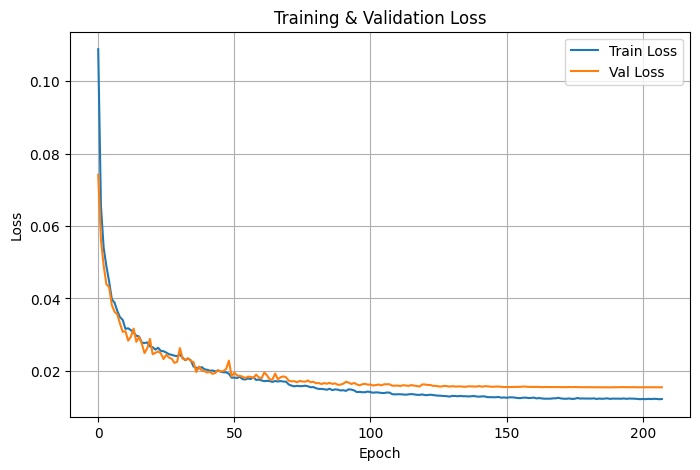

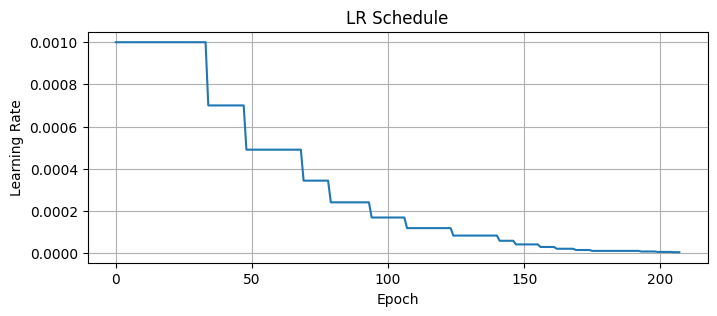

In [73]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

#'''
# --- Dataset & DataLoaders ---
full_dataset = RCDataset("data.npy")
mag_scaler, phase_scaler, y_scaler = full_dataset.mag_scaler, full_dataset.phase_scaler, full_dataset.y_scaler

# Train / val / test split
total_len = len(full_dataset)
train_len = int(0.7 * total_len)
val_len = int(0.3 * total_len)

train_dataset, val_dataset = random_split(full_dataset, [train_len, val_len])
#'''

# batch size
bs = 32

train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=bs, shuffle=False)

# --- Model, criterion, optimizer ---
model = RCNet().to(device)
criterion = nn.SmoothL1Loss(beta=2.0)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)

# --- Train the model ---
history = train_model(
    model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=300, patience=20, plot=True
)

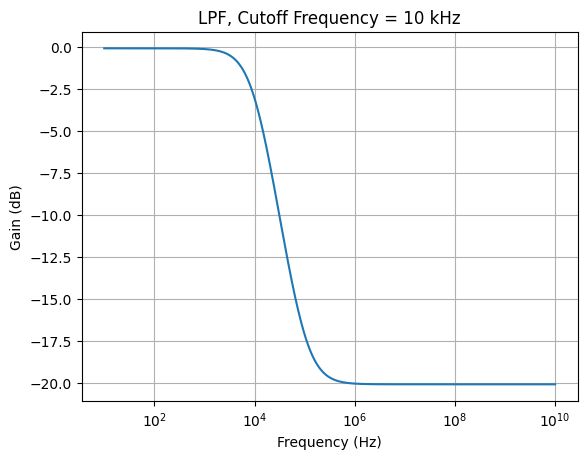

[[1.8029515e+03 9.8601734e+04 1.0526859e-09 8.8588274e-09]]


In [74]:
f = np.logspace(np.log10(10), np.log10(10E9), 9*200)

fc = 10E3
z1 = 10**(np.log10(fc)+1) # minus 1 for high pass, plus 1 for low pass
a = 0.99 # 0.1 for high pass, 0.99 for low pass

hf = a*(1 + 1j*f/z1)/(1 + 1j*f/fc)
plt.semilogx(f,20*np.log10(np.abs(hf)))
plt.grid()
plt.xlabel("Frequency (Hz)")
plt.ylabel("Gain (dB)")
plt.title("LPF, Cutoff Frequency = 10 kHz")
plt.show()

mag = mag_scaler.transform([20*np.log10(np.abs(hf))])
phase = phase_scaler.transform([np.angle(hf)])
#phase = phase_scaler.transform([np.zeros(900)])

test_X = np.stack((mag, phase), axis=1)
test_X = torch.tensor(test_X, dtype=torch.float32).to(device)

model.eval()
predict = model(test_X)
predict = predict.detach().cpu().numpy()
predict = y_scaler.inverse_transform(predict)

predict = 10**predict

print(predict)

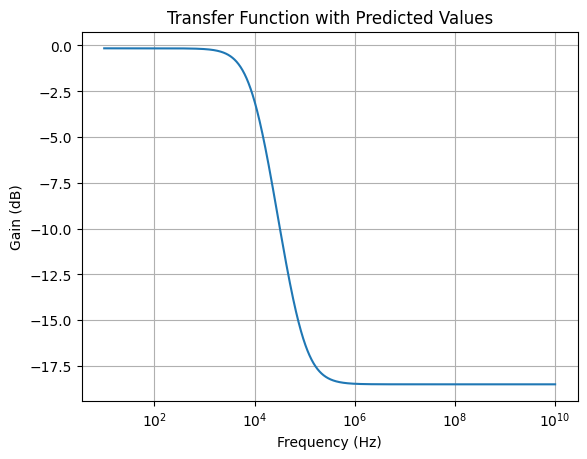

In [75]:
R1, R2, C1, C2 = predict[0]
Req = R1*R2/(R1 + R2)
yf = (R2/(R1+R2))*(1 + 1j*2*np.pi*f*R1*C1)/(1 + 1j*2*np.pi*f*Req*C2)
plt.semilogx(f,20*np.log10(np.abs(yf)))
#plt.semilogx(f,np.angle(yf))
plt.grid()
plt.xlabel("Frequency (Hz)")
plt.ylabel("Gain (dB)")
plt.title("Transfer Function with Predicted Values")
plt.show()

In [1]:
(10E3-8.9E3)/10E3*100

11.0